<a href="https://colab.research.google.com/github/AxisAngeles/Smart_Data_DS_AI/blob/main/S09_EDA_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Unidad 9 – Análisis Exploratorio de Datos (EDA) + BONUS ML (XGBoost)

### 🎯 Objetivos de aprendizaje
Al finalizar, el estudiante podrá:
1) Explicar qué es EDA y por qué es obligatorio antes de modelar.  
2) Hacer exploración inicial: tamaño, tipos de variables, target, nulos, duplicados.  
3) Realizar EDA univariado y bivariado con **gráficos simples**.  
4) Detectar outliers con **boxplot + IQR** y aplicar un tratamiento inicial (capping/log).  
5) Hacer un **primer filtro de variables** y seleccionar variables candidatas.  
6) (BONUS) Ver un **pipeline mínimo** con **XGBoost** y entender “lo que viene” en ML.

---
## Dataset
**UCI – Bank Marketing (bank-full.csv)**  
- Target: `y` (yes/no)  
- Mezcla de variables numéricas y categóricas  
- Caso real de campañas de marketing bancario (muy útil para “pensar como data scientist”)

⚠️ Importante (best practice): algunas variables pueden ser **leakage** (p. ej., `duration` en estos datasets suele estar disponible *después* de la llamada). Lo discutiremos.


## 0) Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

np.random.seed(42)

# 1) Carga de datos (1 línea)
> Regla práctica: **primero carga y mira**, luego decides qué preguntas hacer.

Usaremos un dataset de UCI en CSV con separador `;`.


In [3]:
#Carga de Dataset
file = 'https://raw.githubusercontent.com/AxisAngeles/Smart_Data_DS_AI/main/Sesion_9_bank_full.csv'
df = pd.read_csv(file,sep=";")
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


# 2) Exploración inicial (EDA básico)
Checklist mínimo:
- Tamaño (`shape`)
- Columnas
- Target (balance / proporción)
- Tipos de datos
- Nulos
- Duplicados


In [4]:

df.shape


(45211, 17)

In [5]:

df.columns.tolist()


['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

## 2.1 Target: distribución (¿desbalanceado?)

In [6]:

df['y'].value_counts()


,count
y,
no,39922
yes,5289


In [7]:

df['y'].value_counts(normalize=True)

,proportion
y,
no,0.883015
yes,0.116985


**Interpretación típica esperada:**  
- Este dataset suele estar **desbalanceado**: la clase `yes` es minoritaria.  
- Esto te prepara para métricas como ROC-AUC (más robusta que accuracy en desbalance).  


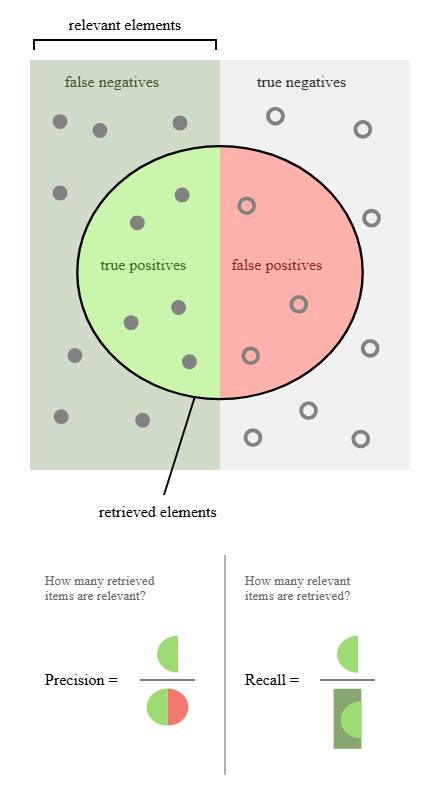

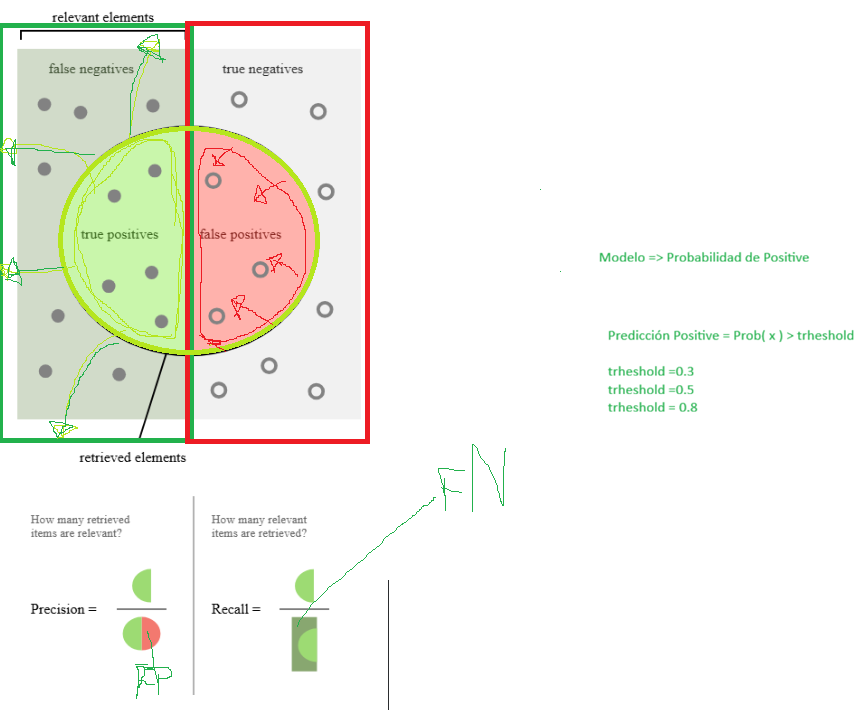

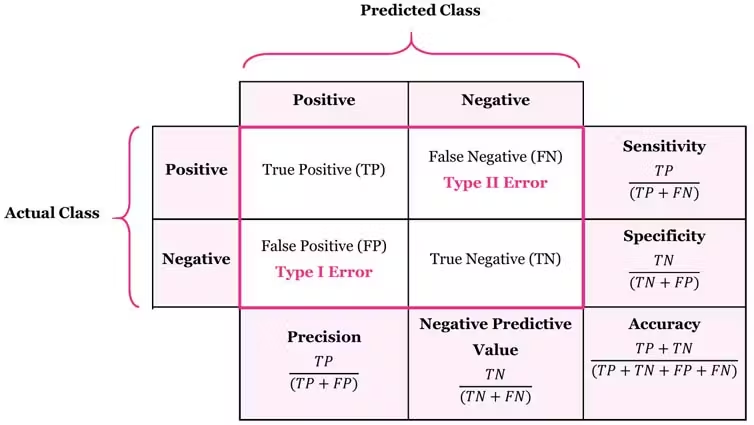

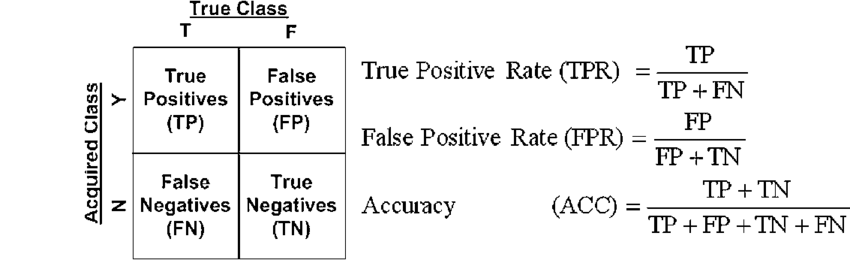

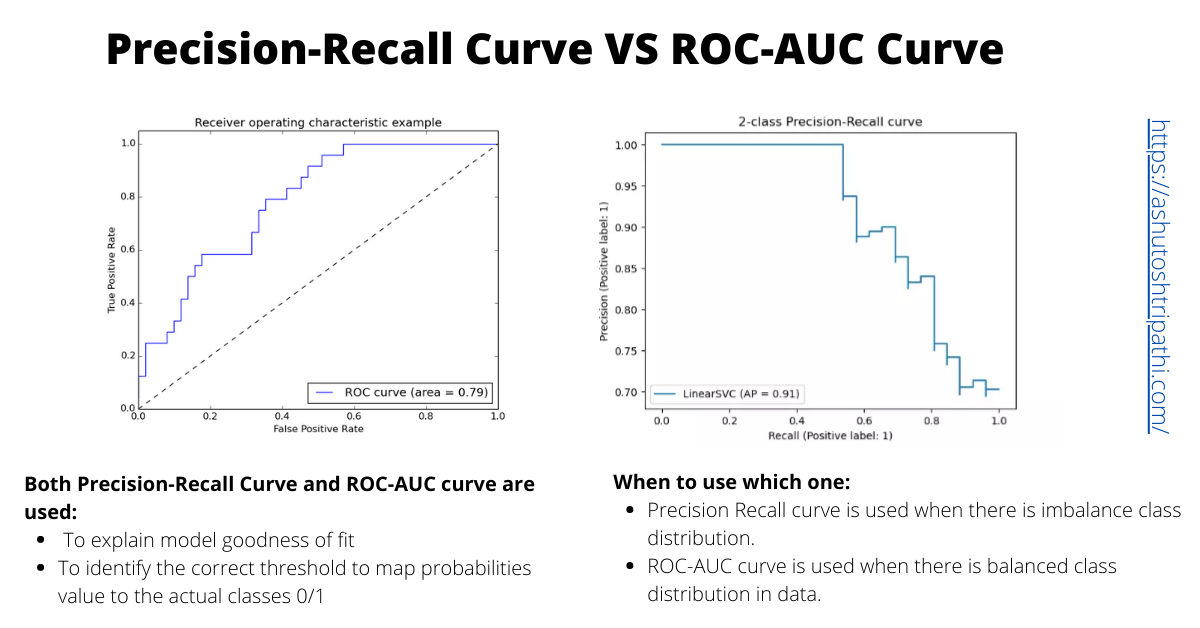

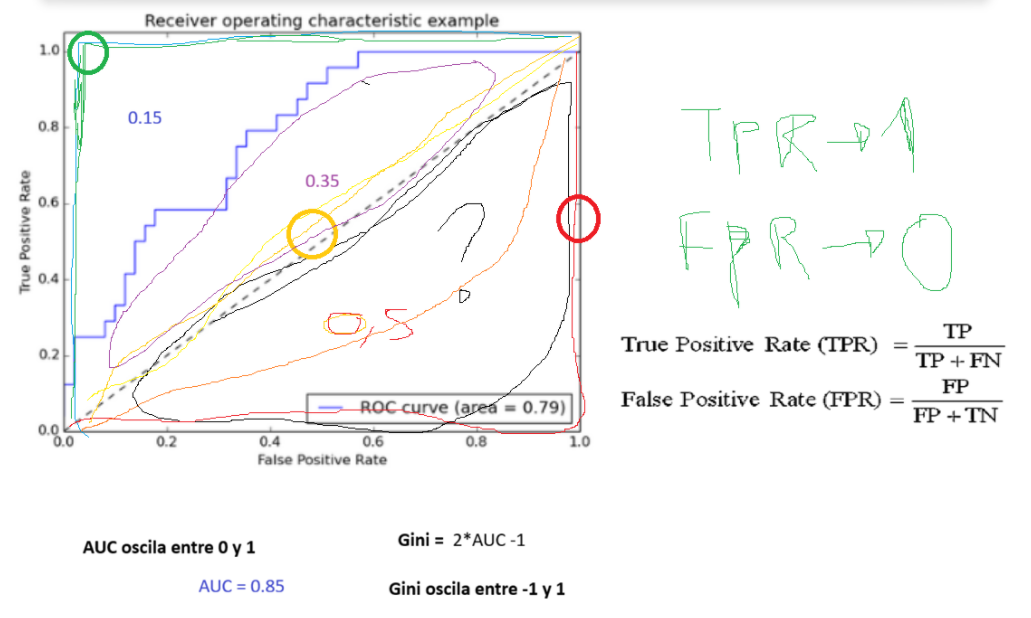

### **Por qué ROC-AUC y Gini son más Robustos en Datasets Desbalanceados**

Imagina un escenario donde solo el 10% de tus clientes aceptan una oferta de marketing (clase 'yes') y el 90% la rechaza (clase 'no').

Si construyes un modelo que simplemente predice 'no' para todos los clientes, tu accuracy será del 90%. A primera vista, esto parece un modelo excelente. Sin embargo, este modelo es completamente inútil porque no identifica a ninguno de los clientes que sí aceptan la oferta, que son precisamente los que te interesan.

La accuracy se calcula como: `(Verdaderos Positivos + Verdaderos Negativos) / Total de Observaciones`. En un dataset desbalanceado, un modelo puede lograr una alta accuracy simplemente prediciendo la clase mayoritaria la mayor parte del tiempo, ignorando por completo la clase minoritaria.

### **ROC (Receiver Operating Characteristic) Curve y AUC (Area Under the ROC Curve)**

1.  **Curva ROC:** Es un gráfico que muestra el rendimiento de un modelo de clasificación en todos los umbrales posibles. Utiliza dos métricas:
    *   **Tasa de Verdaderos Positivos (True Positive Rate - TPR)** o *Recall* (Sensibilidad): Cuántos de los 'yes' reales fueron correctamente identificados.
    *   **Tasa de Falsos Positivos (False Positive Rate - FPR)**: Cuántos de los 'no' reales fueron incorrectamente identificados como 'yes'.

2.  **AUC (Area Under the ROC Curve):** Es el área bajo la curva ROC, con un valor entre 0 y 1.
    *   Un AUC de 0.5 indica un rendimiento aleatorio (no mejor que adivinar).
    *   Un AUC de 1.0 indica un clasificador perfecto.
    *   La gran ventaja del AUC es que es **insensible al desbalance de clases**. Un modelo con un buen AUC significa que es capaz de distinguir bien entre las clases minoritaria y mayoritaria en diferentes umbrales de decisión. Esto es crucial cuando la clase minoritaria es la de interés, ya que el AUC evalúa la capacidad del modelo para *ordenar* correctamente las probabilidades de los ejemplos positivos por encima de los negativos.

### **Coeficiente de Gini**

*   El coeficiente de Gini está directamente relacionado con el AUC mediante la fórmula: `Gini = 2 * AUC - 1`.
*   Al igual que el AUC, el Gini es una métrica robusta frente al desbalance de clases porque se enfoca en la capacidad discriminatoria del modelo, es decir, qué tan bien el modelo puede separar las clases, en lugar de solo contar los aciertos absolutos.

### **En Resumen:**

Cuando la clase de interés es minoritaria, la *accuracy* puede ser engañosa porque un modelo puede lograr una alta precisión prediciendo la clase mayoritaria. Métricas como ROC-AUC o Gini son superiores porque evalúan la capacidad del modelo para diferenciar entre las clases en todos los posibles puntos de corte, proporcionando una visión más real y robusta del rendimiento predictivo, especialmente para la clase minoritaria que suele ser la de mayor interés de negocio.

## 2.2 Tipos de variables

In [8]:

df.dtypes


,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


## 2.3 Nulos y duplicados

In [9]:

df.isna().sum().sort_values(ascending=False).head(20)


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [10]:

df.duplicated().sum()


np.int64(0)

**Interpretación típica esperada:**  
- Muchas veces este dataset no trae nulos “NaN”, sino categorías como `"unknown"`.
- Los duplicados pueden existir o no; si existen, se decide si son registros válidos.


## 2.4 Valores 'unknown' como faltantes (best practice simple)

In [11]:

# Contar 'unknown' en variables categóricas
cat_cols = [c for c in df.columns if df[c].dtype == 'object' and c != 'y']
unknown_counts = {c: (df[c] == 'unknown').sum() for c in cat_cols}
pd.Series(unknown_counts).sort_values(ascending=False).head(15)


,0
poutcome,36959
contact,13020
education,1857
job,288
marital,0
housing,0
default,0
loan,0
month,0


# 3) EDA univariado – variables numéricas
Buenas preguntas:
- ¿Cómo se distribuye cada variable?
- ¿Hay colas largas? ¿outliers?
- ¿media vs mediana cambian mucho?

Trabajaremos con un subconjunto “útil” y entendible:
`age`, `duration`, `campaign`, `pdays`, `previous`, `euribor3m`, `emp.var.rate` (si existen), etc.

*(En este dataset particular hay muchas columnas; elegimos algunas con sentido.)*


In [12]:

# Selecciona numéricas automáticamente (y luego escogemos algunas)
num_cols = [c for c in df.columns if df[c].dtype != 'object' and c != 'y']
len(num_cols), num_cols[:15]


(7, ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'])

In [13]:

df[num_cols].describe().T.head(15)


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


## 3.1 Histogramas simples (3 variables)

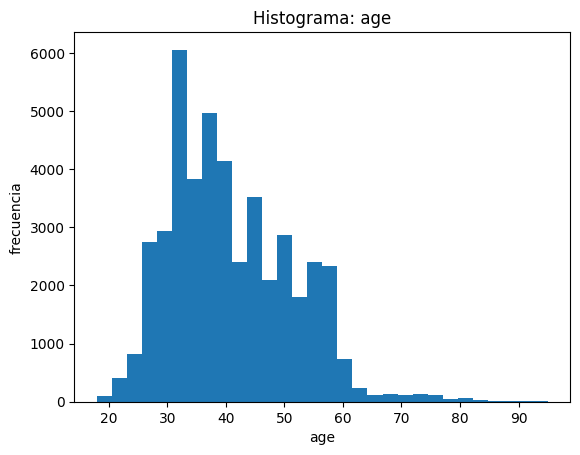

In [14]:

plt.figure()
plt.hist(df['age'], bins=30)
plt.title("Histograma: age")
plt.xlabel("age"); plt.ylabel("frecuencia")
plt.show()


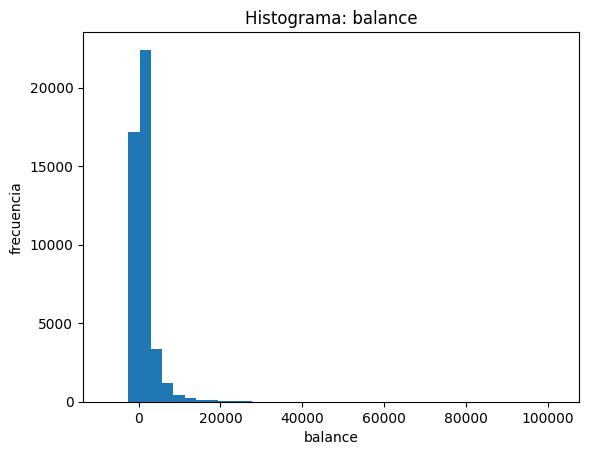

In [15]:

plt.figure()
plt.hist(df['balance'], bins=40)
plt.title("Histograma: balance")
plt.xlabel("balance"); plt.ylabel("frecuencia")
plt.show()


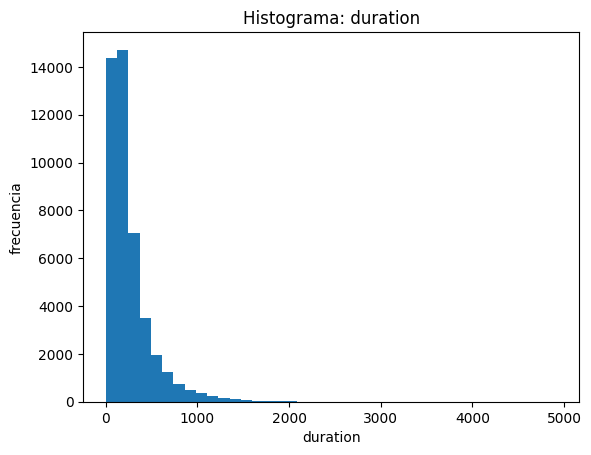

In [16]:

plt.figure()
plt.hist(df['duration'], bins=40)
plt.title("Histograma: duration")
plt.xlabel("duration"); plt.ylabel("frecuencia")
plt.show()


**Hallazgo típico esperado:**  
- `balance` suele ser asimétrica (cola larga) y con valores extremos.  
- `duration` suele ser muy predictiva, pero es sospechosa de leakage (depende de cuándo se conoce).  


## 3.2 Boxplots simples (detectar outliers visualmente)

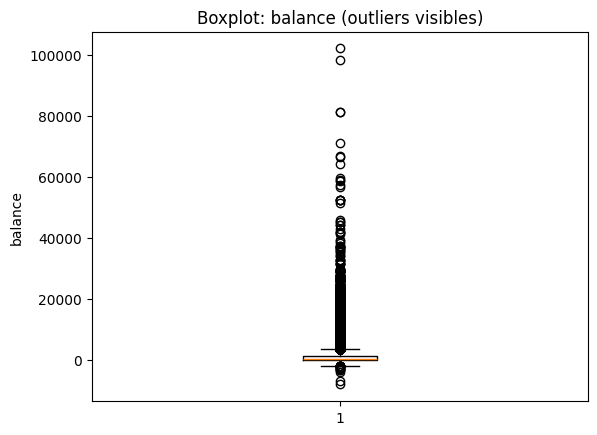

In [17]:

plt.figure()
plt.boxplot(df['balance'])
plt.title("Boxplot: balance (outliers visibles)")
plt.ylabel("balance")
plt.show()


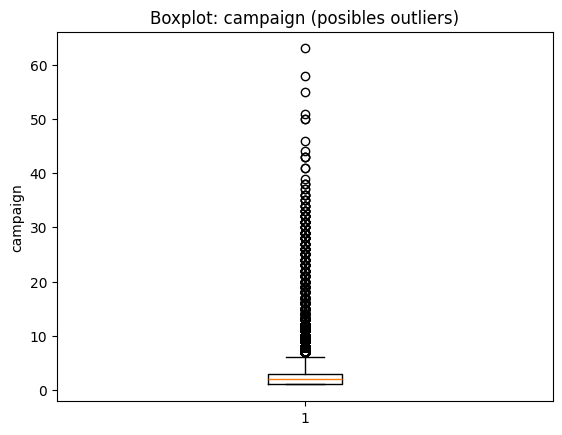

In [ ]:

plt.figure()
plt.boxplot(df['campaign'])
plt.title("Boxplot: campaign (posibles outliers)")
plt.ylabel("campaign")
plt.show()


# 4) EDA univariado – variables categóricas
Preguntas:
- ¿Cuáles son las categorías más frecuentes?
- ¿Hay categorías raras?
- ¿Existen muchos "unknown"?

Mostraremos ejemplos con: `job`, `education`, `marital`, `housing`, `loan`.


In [18]:

# Frecuencias simples
df['job'].value_counts().head(10)


,count
job,
blue-collar,9732
management,9458
technician,7597
admin.,5171
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303


In [19]:

df['education'].value_counts().head(10)


,count
education,
secondary,23202
tertiary,13301
primary,6851
unknown,1857


## 4.1 Gráfico de barras simple (top categorías)

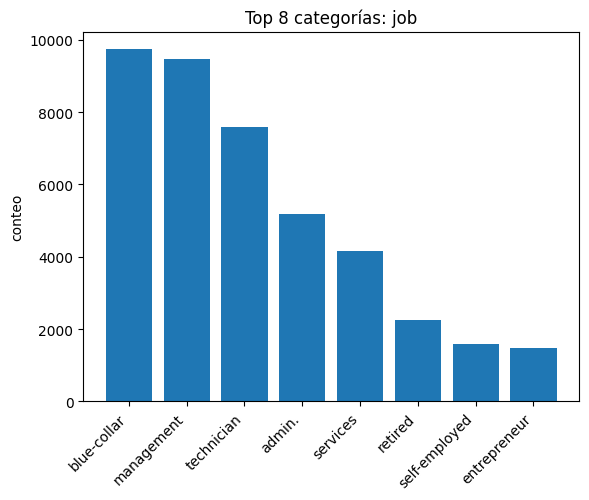

In [20]:

top_jobs = df['job'].value_counts().head(8)
plt.figure()
plt.bar(top_jobs.index.astype(str), top_jobs.values)
plt.title("Top 8 categorías: job")
plt.xticks(rotation=45, ha='right')
plt.ylabel("conteo")
plt.show()


**Hallazgo típico esperado:**  
- Algunas categorías dominan (ej. admin, technician, blue-collar).  
- `education` y `job` pueden tener `"unknown"` o categorías muy poco frecuentes.  


# 5) EDA bivariado – relación con el target
Aquí buscamos “señales”:
- numérica vs target: medianas por clase + boxplot por clase  
- categórica vs target: tasa de `yes` por categoría (muy didáctico)

👉 Importante: **correlación / asociación ≠ causalidad**.


## 5.1 Numéricas vs target (medianas y boxplot)

In [21]:

# Convertir target a 0/1 para cálculos simples
df['y_bin'] = (df['y'] == 'yes').astype(int)
df.groupby('y')['balance'].median()


,balance
y,
no,417.0
yes,733.0


<Figure size 640x480 with 0 Axes>

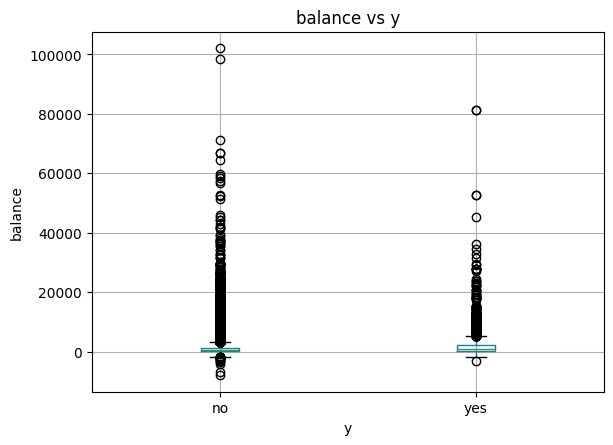

In [22]:

plt.figure()
df.boxplot(column='balance', by='y')
plt.title("balance vs y")
plt.suptitle("")
plt.ylabel("balance")
plt.show()


In [23]:

df.groupby('y')['age'].median()


,age
y,
no,39.0
yes,38.0


<Figure size 640x480 with 0 Axes>

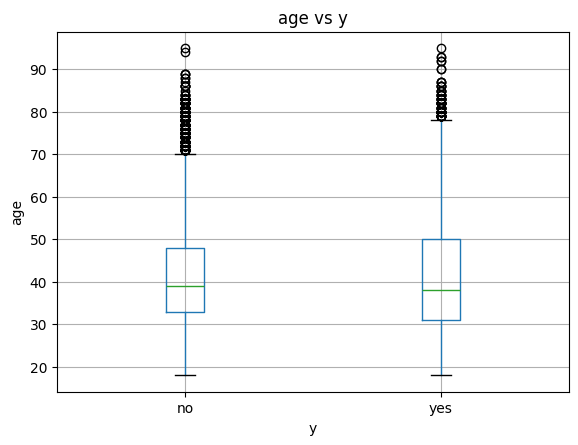

In [24]:

plt.figure()
df.boxplot(column='age', by='y')
plt.title("age vs y")
plt.suptitle("")
plt.ylabel("age")
plt.show()


**Hallazgos típicos esperados (no garantizados):**
- `duration` suele separar mucho `yes` vs `no` (pero revisa leakage).
- Variables macro del dataset (si están: euribor3m, emp.var.rate) a veces influyen por contexto económico.


## 5.3 Correlación de variables numéricas

Analizaremos la correlación entre las variables numéricas, incluyendo el target binarizado (`y_bin`), para identificar posibles relaciones lineales. Esto nos puede dar una idea temprana de qué variables podrían ser más predictivas.

In [25]:
import seaborn as sns

# Asegurar que 'y_bin' esté creada
df['y_bin'] = (df['y'] == 'yes').astype(int)

# Asegurar que 'balance_cap' esté creada, recalculando lower y upper si es necesario
# Estos valores se calculan en una celda previa, los volvemos a definir aquí para robustez
q1 = df['balance'].quantile(0.25)
q3 = df['balance'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
df['balance_cap'] = df['balance'].clip(lower, upper)


# Incluir las variables numéricas candidatas y el target binarizado
num_vars_for_corr = ['age', 'balance_cap', 'campaign', 'pdays', 'previous'] + ['y_bin']
correlation_matrix = df[num_vars_for_corr].corr()

print("Matriz de Correlación de Variables Numéricas:")
display(correlation_matrix)

Matriz de Correlación de Variables Numéricas:


,age,balance_cap,campaign,pdays,previous,y_bin
age,1.000000,0.122118,0.004760,-0.023758,0.001288,0.025155
balance_cap,0.122118,1.000000,-0.029168,0.017160,0.035308,0.092924
campaign,0.004760,-0.029168,1.000000,-0.088628,-0.032855,-0.073172
pdays,-0.023758,0.017160,-0.088628,1.000000,0.454820,0.103621
previous,0.001288,0.035308,-0.032855,0.454820,1.000000,0.093236
y_bin,0.025155,0.092924,-0.073172,0.103621,0.093236,1.000000


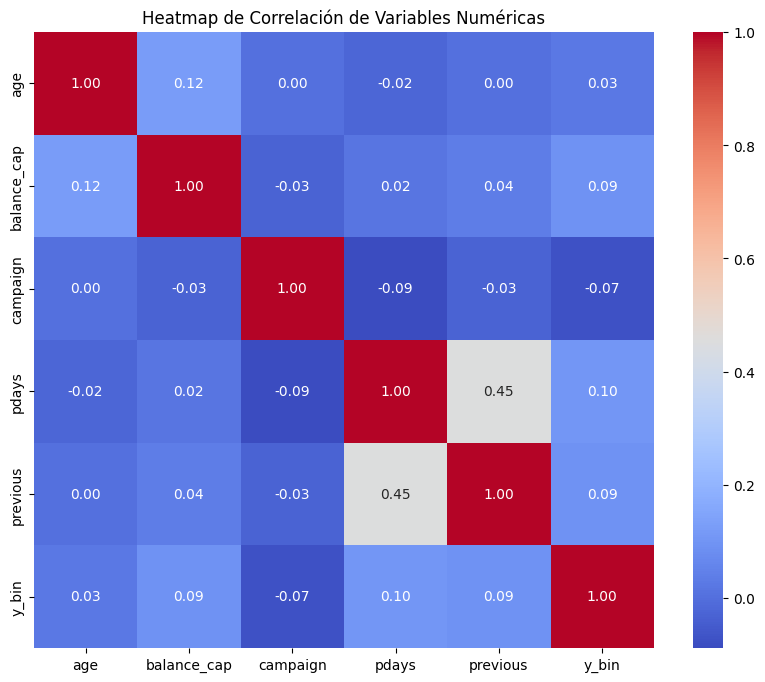

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap de Correlación de Variables Numéricas')
plt.show()

## 5.2 Categóricas vs target: tasa de 'yes' por categoría

In [27]:

# Tasa de yes por job (simple)
job_rate = df.groupby('job')['y_bin'].mean().sort_values(ascending=False)
job_rate.head(10)


,y_bin
job,
student,0.286780
retired,0.227915
unemployed,0.155027
management,0.137556
admin.,0.122027
self-employed,0.118429
unknown,0.118056
technician,0.110570
services,0.088830


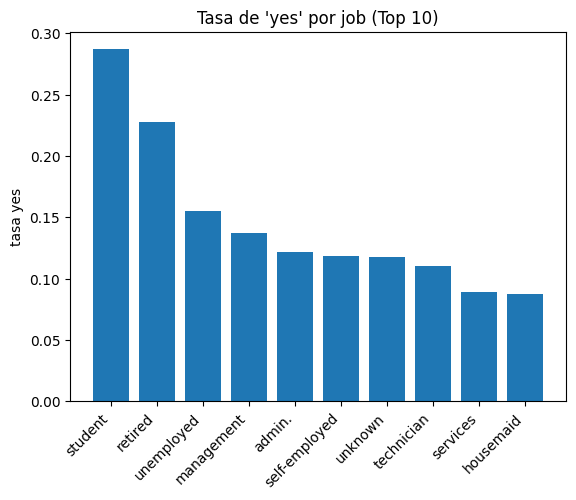

In [28]:

# Gráfico simple: top 10 por tasa (ordenado)
top10 = job_rate.head(10)
plt.figure()
plt.bar(top10.index.astype(str), top10.values)
plt.title("Tasa de 'yes' por job (Top 10)")
plt.xticks(rotation=45, ha='right')
plt.ylabel("tasa yes")
plt.show()


In [29]:

# Tasa de yes por housing (sí/no/unknown)
df.groupby('housing')['y_bin'].mean().sort_values(ascending=False)


,y_bin
housing,
no,0.167024
yes,0.077000


# 6) Outliers: detección y “soluciones” (primer tratamiento)
## 6.1 Detección con IQR (balance)
Recordatorio:
- Q1, Q3, IQR = Q3-Q1
- lower = Q1 - 1.5*IQR
- upper = Q3 + 1.5*IQR


In [30]:

q1 = df['balance'].quantile(0.25)
q3 = df['balance'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

outliers_balance = df[(df['balance'] < lower) | (df['balance'] > upper)]
len(outliers_balance), lower, upper


(4729, np.float64(-1962.0), np.float64(3462.0))

## 6.2 ¿Qué hacer con outliers? (best practice explicable)
Opciones típicas:
1) **Validar si es error** (edad negativa, valores imposibles)  
2) **Capping/Winsorization** (recortar a límites)  
3) **Transformación log** (si hay colas largas)  
4) Eliminar outliers (solo si hay evidencia de error)


### 6.3 Solución 1: Capping (recomendación por defecto)

In [31]:

df['balance_cap'] = df['balance'].clip(lower, upper)
df[['balance','balance_cap']].describe()


,balance,balance_cap
count,45211.000000,45211.000000
mean,1362.272058,933.706974
std,3044.765829,1176.765369
min,-8019.000000,-1962.000000
25%,72.000000,72.000000
50%,448.000000,448.000000
75%,1428.000000,1428.000000
max,102127.000000,3462.000000


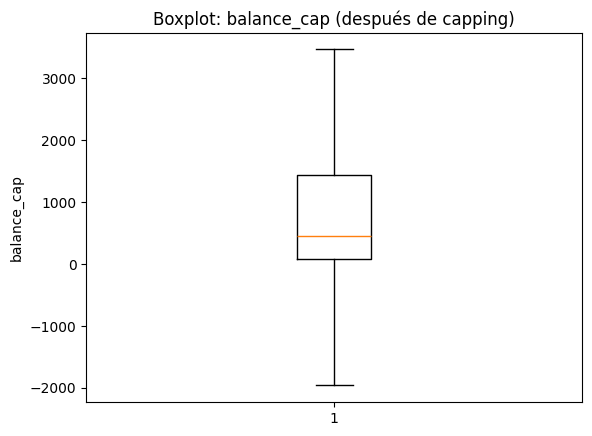

In [32]:

plt.figure()
plt.boxplot(df['balance_cap'])
plt.title("Boxplot: balance_cap (después de capping)")
plt.ylabel("balance_cap")
plt.show()


### 6.4 Solución 2: Transformación log1p (cuando hay cola larga)

In [33]:

# log1p(x) = log(1+x) evita problemas con 0
# Nota: si balance puede ser negativo, hacemos un shift simple (best practice básica)
min_bal = df['balance'].min()
shift = 0
if min_bal <= 0:
    shift = abs(min_bal) + 1

df['balance_shift'] = df['balance'] + shift
df['balance_log'] = np.log1p(df['balance_shift'])

df[['balance','balance_shift','balance_log']].head()


,balance,balance_shift,balance_log
0,2143,10163,9.226607
1,29,8049,8.993427
2,2,8022,8.990068
3,1506,9526,9.161885
4,1,8021,8.989943


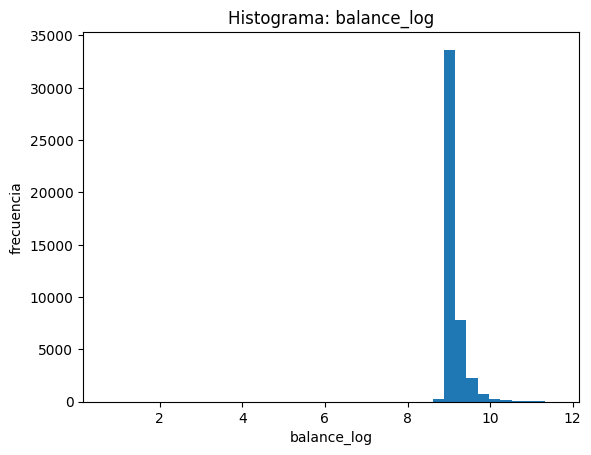

In [34]:

plt.figure()
plt.hist(df['balance_log'], bins=40)
plt.title("Histograma: balance_log")
plt.xlabel("balance_log"); plt.ylabel("frecuencia")
plt.show()


# 7) Primer filtro de variables y selección de candidatas
Objetivo: armar una lista razonable de variables candidatas **sin** hacer selección avanzada.

## Checklist simple:
- Quitar columnas irrelevantes / ID-like (si existieran)
- Revisar variables con demasiados `"unknown"`
- Revisar variables numéricas con demasiados outliers extremos
- Evitar leakage (variables que se conocen después del evento)

### ⚠️ Leakage típico en este tipo de datasets:
- `duration` (duración de llamada) suele conocerse *después* de la interacción; si modelas “antes”, no deberías usarla.


In [35]:

# Revisión simple de unknown ratio por categórica
unknown_ratio = {c: (df[c]=='unknown').mean() for c in cat_cols}
unknown_ratio_sorted = pd.Series(unknown_ratio).sort_values(ascending=False)
unknown_ratio_sorted.head(15)


,0
poutcome,0.817478
contact,0.287983
education,0.041074
job,0.006370
marital,0.000000
housing,0.000000
default,0.000000
loan,0.000000
month,0.000000


## 7.1 Selección candidata

In [36]:

# Propuesta: evitamos duration por posible leakage
# (puedes mostrar 2 modelos: con y sin duration, para enseñar el concepto)

# Recojo algunas numéricas (depende del dataset exacto, ajusta si faltan)
candidate_num = [c for c in ['age','balance_cap','campaign','pdays','previous'] if c in df.columns]

# Recojo algunas categóricas claras
candidate_cat = [c for c in ['job','marital','education','housing','loan','contact','month'] if c in df.columns]

candidate_num, candidate_cat


(['age', 'balance_cap', 'campaign', 'pdays', 'previous'],
 ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month'])

## 7.2 Señales simples para priorizar variables (sin técnicas avanzadas)

In [37]:

# Señal numérica: diferencia de medianas por clase (yes/no)
signals = []
for c in candidate_num:
    med_yes = df[df['y']=='yes'][c].median()
    med_no  = df[df['y']=='no'][c].median()
    signals.append((c, med_yes, med_no, med_yes - med_no))

pd.DataFrame(signals, columns=['var','median_yes','median_no','diff']).sort_values('diff', ascending=False)


,var,median_yes,median_no,diff
1,balance_cap,733.0,417.0,316.0
3,pdays,-1.0,-1.0,0.0
2,campaign,2.0,2.0,0.0
4,previous,0.0,0.0,0.0
0,age,38.0,39.0,-1.0


In [38]:

# Señal categórica: tasas de yes por categoría (ejemplo con housing)
if 'housing' in df.columns:
    print(df.groupby('housing')['y_bin'].mean().sort_values(ascending=False))


housing
no     0.167024
yes    0.077000
Name: y_bin, dtype: float64


# 8) BONUS – Pipeline mínimo con XGBoost (teaser)
### Objetivo del bonus
Mostrar que:
- Cuando el EDA está bien hecho (outliers + variables + encoding)  
- Un modelo puede empezar a funcionar *rápidamente*

⚠️ Esto NO reemplaza las clases de ML posteriores. Es solo una vista previa.


In [39]:

# Preparar X/y
X = df[candidate_num + candidate_cat].copy()
y = df['y_bin'].copy()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Preprocesamiento: num passthrough + onehot categóricas
preprocess = ColumnTransformer([
    ('num', 'passthrough', candidate_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), candidate_cat)
])

# Modelo XGBoost simple
xgb = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    eval_metric='logloss',
    random_state=42
)

pipe = Pipeline([('prep', preprocess), ('model', xgb)])
pipe


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'balance_cap',
                                                   'campaign', 'pdays',
                                                   'previous']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'housing',
                                                   'loan', 'contact',
                                                   'month'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynod...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.08,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=250, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [40]:

pipe.fit(X_train, y_train)

probs = pipe.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, probs)
auc

np.float64(0.7817827847840476)

In [41]:
probs

array([0.18661088, 0.7158513 , 0.02917814, ..., 0.19540687, 0.18463895,
       0.11499052], dtype=float32)

In [42]:
y_test

,y_bin
37735,1
44332,1
4432,0
38725,1
38581,0
...,...
15913,0
20622,1
41684,0
32749,0


In [43]:

preds = (probs >= 0.5).astype(int)
confusion_matrix(y_test, preds)


array([[11774,   203],
       [ 1276,   311]])

F1 score = 2 * precision * recall / (precision + recall)

In [44]:

print(classification_report(y_test, preds, digits=3))


              precision    recall  f1-score   support

           0      0.902     0.983     0.941     11977
           1      0.605     0.196     0.296      1587

    accuracy                          0.891     13564
   macro avg      0.754     0.590     0.618     13564
weighted avg      0.867     0.891     0.865     13564




Umbral óptimo que maximiza F1-score: 0.1828
F1-score en el umbral óptimo: 0.4715
Precision en el umbral óptimo: 0.4301
Recall en el umbral óptimo: 0.5217


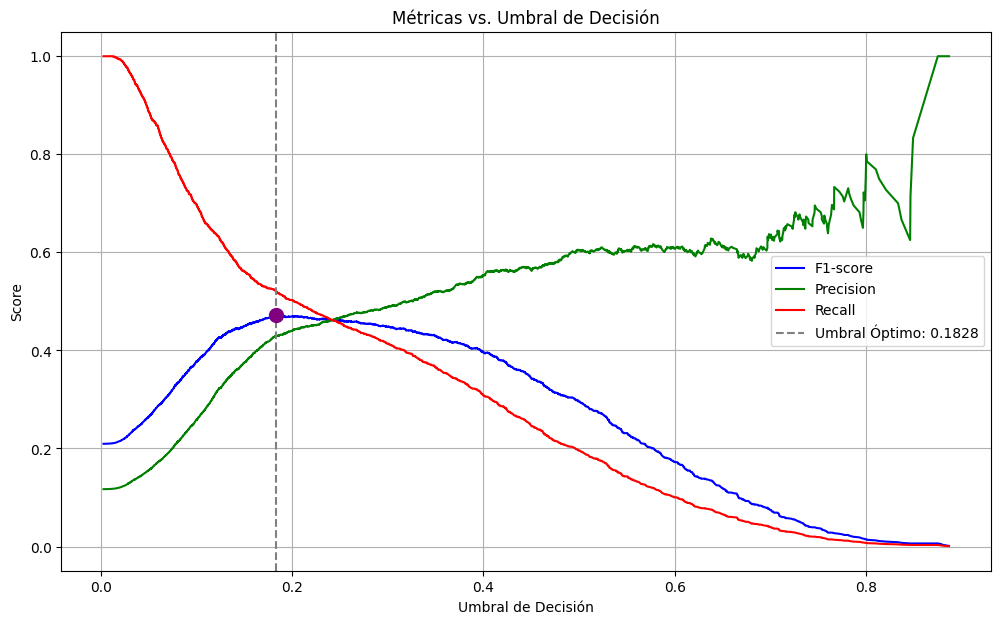

In [45]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities for the positive class
probs = pipe.predict_proba(X_test)[:, 1]

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Calculate F1-score for each threshold
f1_scores = []
for p, r in zip(precision, recall):
    if (p + r) == 0: # Handle division by zero
        f1_scores.append(0.0)
    else:
        f1_scores.append(2 * (p * r) / (p + r))

# Find the optimal threshold that maximizes F1-score
optimal_threshold_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_threshold_idx]
optimal_f1 = f1_scores[optimal_threshold_idx]
optimal_precision = precision[optimal_threshold_idx]
optimal_recall = recall[optimal_threshold_idx]

# Print the optimal threshold and corresponding metrics
print(f"\nUmbral óptimo que maximiza F1-score: {optimal_threshold:.4f}")
print(f"F1-score en el umbral óptimo: {optimal_f1:.4f}")
print(f"Precision en el umbral óptimo: {optimal_precision:.4f}")
print(f"Recall en el umbral óptimo: {optimal_recall:.4f}")

# Plot F1-score, Precision, and Recall vs. thresholds
plt.figure(figsize=(12, 7))
plt.plot(thresholds, f1_scores[:-1], label='F1-score', color='blue') # F1-score curve
plt.plot(thresholds, precision[:-1], label='Precision', color='green') # Precision curve
plt.plot(thresholds, recall[:-1], label='Recall', color='red') # Recall curve

# Mark the optimal threshold on the plot
plt.axvline(optimal_threshold, color='gray', linestyle='--', label=f'Umbral Óptimo: {optimal_threshold:.4f}')
plt.scatter(optimal_threshold, optimal_f1, color='purple', marker='o', s=100, zorder=5)

plt.xlabel('Umbral de Decisión')
plt.ylabel('Score')
plt.title('Métricas vs. Umbral de Decisión')
plt.grid(True)
plt.legend()
plt.show()

In [46]:

preds = (probs >= 0.1828).astype(int)
confusion_matrix(y_test, preds)
print(classification_report(y_test, preds, digits=3))



              precision    recall  f1-score   support

           0      0.935     0.908     0.921     11977
           1      0.430     0.521     0.471      1587

    accuracy                          0.863     13564
   macro avg      0.682     0.715     0.696     13564
weighted avg      0.876     0.863     0.869     13564



## 8.1 Feature importance (vista simple)
XGBoost tiene importancias internas.  
Como usamos OneHotEncoder, el número de features aumenta. Vamos a recuperar nombres.


In [47]:

# Obtener nombres de features después del preprocesamiento
ohe = pipe.named_steps['prep'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(candidate_cat)
feature_names = list(candidate_num) + list(cat_feature_names)

importances = pipe.named_steps['model'].feature_importances_
imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp.sort_values('importance', ascending=False).head(15)


,feature,importance
30,contact_unknown,0.136519
25,housing_yes,0.126518
24,housing_no,0.086798
38,month_mar,0.065336
37,month_jun,0.049019
31,month_apr,0.042081
41,month_oct,0.035803
42,month_sep,0.034805
4,previous,0.026806
33,month_dec,0.025058


**Interpretación típica esperada:**  
- Algunas categorías (mes/contacto/job) tienden a aportar señal.  
- Si incluyes `duration`, la performance sube mucho (y eso es una bandera de leakage).


# 9) ¿Cómo elegir el algoritmo ML correcto?
## Respuesta estructurada (para tu alumno)
**Paso 1: define el tipo de problema**
- Clasificación (0/1), regresión (continuo), clustering, NLP, series.

**Paso 2: define la restricción principal**
- Interpretabilidad (regulación, riesgo)  
- Performance (competencia / producto)  
- Tiempo (entrenamiento y despliegue)  
- Datos (cantidad y calidad)

**Paso 3: estrategia recomendada**
1) Baseline simple (Logistic Regression) → referencia mínima  
2) Árboles/RandomForest → robustos y fáciles en tabular  
3) Boosting (XGBoost/LightGBM) → **alto desempeño** en tabular  
4) Redes neuronales → cuando hay mucho dato y casos específicos (imagen, texto, etc.)

**Regla de oro:**
> “No elijas por moda. Elige por: problema + restricciones + datos + baseline.”


# 10) Hallazgos y conclusiones esperables (lo que suele salir en este dataset)
**(Estas son conclusiones típicas; verifica con tus resultados en clase)**

1) **El target suele estar desbalanceado** (pocos `yes`).  
2) `duration` suele ser extremadamente “predictiva”, pero es **leakage** si el score se usa antes de la llamada.  
3) Variables de campaña (`campaign`, `pdays`, `previous`) suelen tener señal: reflejan historia de contacto.  
4) Algunas categorías de `job`, `education`, `month` tienden a mostrar diferencias en tasa de suscripción.  
5) `balance` tiende a ser asimétrica: outliers visibles; el **capping/log** mejora estabilidad del modelo.

**Mensaje final:**  
> EDA no es “hacer gráficos”. Es *tomar decisiones correctas* sobre datos, variables y supuestos.


# 🧩 Ejercicios extra (para extender o dejar de tarea)
1) Repite el análisis de outliers para `campaign` y decide tratamiento.  
2) Calcula la tasa de `yes` por `month` y grafícala.  
3) Entrena 2 modelos: con `duration` y sin `duration` y compara AUC (leakage demo).  
4) Crea una lista final de 10 variables y justifica por qué (negocio + datos).  
5) Escribe 5 insights de negocio como si fueras a mandar un email al gerente.
